In [1]:
import torch
import gc
from diffusers import StableDiffusion3InpaintPipeline

pipe = StableDiffusion3InpaintPipeline.from_pretrained(
    "stabilityai/stable-diffusion-3-medium-diffusers",
    torch_dtype=torch.float16,
    text_encoder_3=None,  # drops T5-XXL, saves ~8GB
    tokenizer_3=None,
)
pipe.enable_model_cpu_offload()  # streams layers to avoid OOM



gc.collect()
torch.cuda.empty_cache()
# Optional: If you still hit memory limits later, you can add:
# pipe.enable_model_cpu_offload()



Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

In [2]:
import ipywidgets as widgets
from IPython.display import display

# Create the upload widget
uploader = widgets.FileUpload(
    accept='image/*',  # Restrict to image files
    multiple=False     # We only need one base image at a time
)

display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

Successfully loaded image! Size: (644, 575)


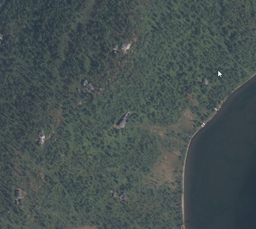

In [3]:
import io
from PIL import Image

# Ensure a file was actually uploaded
if uploader.value:
    # ipywidgets v8+ stores uploads as a tuple of dictionaries
    uploaded_file = uploader.value[0] 
    image_bytes = uploaded_file['content']
    
    # Read the bytes into a PIL Image and ensure it's in standard RGB format
    base_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    
    print(f"Successfully loaded image! Size: {base_image.size}")
    preview = base_image.copy()
    preview.thumbnail((256, 256))  # preserves aspect ratio
    display(preview)
else:
    print("Please select a file using the upload button first.")

In [4]:
from ipycanvas import Canvas, hold_canvas
from PIL import ImageDraw
import numpy as np

# Convert base_image to numpy array for canvas
image_array = np.array(base_image)

# Create a canvas matching the image size (or scale down for performance)
canvas_width, canvas_height = base_image.size
canvas = Canvas(width=canvas_width, height=canvas_height)

# Draw the image on the canvas
canvas.put_image_data(image_array, 0, 0)

# List to store clicked points
points = []

def on_mouse_down(x, y):
    points.append((int(x), int(y)))
    with hold_canvas(canvas):
        canvas.fill_style = 'red'
        canvas.fill_arc(x, y, 4, 0, 2 * np.pi)
        if len(points) > 1:
            canvas.stroke_style = 'red'
            canvas.begin_path()
            canvas.move_to(*points[-2])
            canvas.line_to(*points[-1])
            canvas.stroke()


# Bind the click event (left-click to add point)
canvas.on_mouse_down(on_mouse_down)

# Display the canvas
display(canvas)

print("Click on the canvas to add polygon vertices. Right-click or run the next cell to finish and generate the mask.")

Canvas(height=575, width=644)

Click on the canvas to add polygon vertices. Right-click or run the next cell to finish and generate the mask.


Selected polygon vertices: [(320, 274), (260, 306), (306, 343), (337, 289), (338, 272)]


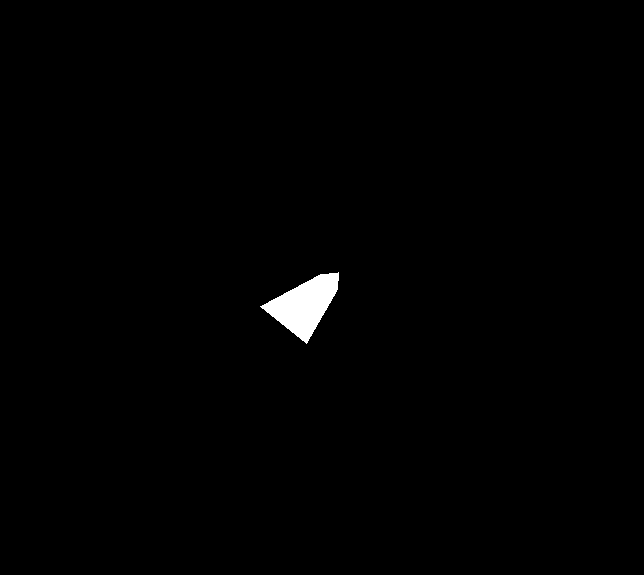

In [5]:
# Run this cell after selecting points on the canvas to create the mask

# Convert points to list of tuples
polygon_vertices = points

print(f"Selected polygon vertices: {polygon_vertices}")

# Create the mask
mask_image = Image.new('L', base_image.size, color=0)  # Black mask
draw = ImageDraw.Draw(mask_image)
if len(polygon_vertices) > 2:
    draw.polygon(polygon_vertices, fill=255)  # White polygon
else:
    print("Need at least 3 points for a polygon.")

# Display the mask
display(mask_image)

In [6]:
prompt_widget = widgets.Textarea(value="aerial satellite view of green grass field, no structures", description="Prompt:")
neg_prompt_widget = widgets.Text(value="blurry, artifacts, buildings, aircraft, runway", description="Negative:")
steps_slider = widgets.IntSlider(value=30, min=10, max=80, description="Steps:")
guidance_slider = widgets.FloatSlider(value=15.0, min=1.0, max=30.0, step=0.5, description="Guidance:")
seed_widget = widgets.IntText(value=42, description="Seed:")
display(prompt_widget, neg_prompt_widget, steps_slider, guidance_slider, seed_widget)


Textarea(value='aerial satellite view of green grass field, no structures', description='Prompt:')

Text(value='blurry, artifacts, buildings, aircraft, runway', description='Negative:')

IntSlider(value=30, description='Steps:', max=80, min=10)

FloatSlider(value=15.0, description='Guidance:', max=30.0, min=1.0, step=0.5)

IntText(value=42, description='Seed:')

In [11]:
w, h = base_image.size
scale = min(1024 / w, 1024 / h)
new_w = (int(w * scale) // 64) * 64
new_h = (int(h * scale) // 64) * 64
base_image_resized = base_image.resize((new_w, new_h), Image.LANCZOS)
mask_image_resized = mask_image.resize((new_w, new_h), Image.LANCZOS)

print(f"Resized to: {new_w}x{new_h}")

if np.array(mask_image_resized).max() == 0:
    print("Warning: The mask is completely black (no area selected for inpainting).")
from PIL import ImageFilter
mask_blurred = mask_image_resized.filter(ImageFilter.GaussianBlur(radius=8))

generator = torch.Generator("cuda").manual_seed(seed_widget.value)
res = pipe(
    prompt_widget.value,
    negative_prompt=neg_prompt_widget.value,
    image=base_image_resized,
    mask_image=mask_blurred,
    height=new_h,
    width=new_w,
    num_inference_steps=steps_slider.value,
    guidance_scale=guidance_slider.value,
    generator=generator,
)

result_image = res.images[0]

import io

def pil_to_png_bytes(img):
    buffer = io.BytesIO()
    img.save(buffer, format='PNG')
    buffer.seek(0)
    return buffer.getvalue()

display(widgets.HBox([
    widgets.VBox([widgets.Label("Original Image"), widgets.Image(value=pil_to_png_bytes(base_image_resized), format='png')]),
    widgets.VBox([widgets.Label("Mask Image"), widgets.Image(value=pil_to_png_bytes(mask_blurred), format='png')]),
    widgets.VBox([widgets.Label("Inpainted Result"), widgets.Image(value=pil_to_png_bytes(result_image), format='png')])
]))
result_image.save("inpaint_result.png")

Resized to: 960x896


  0%|          | 0/18 [00:00<?, ?it/s]

In [9]:
result_image.save("inpaint_result.png")